In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

# What Drives the Price of a Car?
## Applying CRISP-DM Framework

# 1. Business Understanding

A used car dealership aims to better understand the factors that influence used vehicle prices in order to optimize inventory purchasing decisions and improve profitability. The objective of this practical assignment is to identify which vehicle attributes most strongly impact resale value and to develop predictive models capable of estimating vehicle prices.

The CRISP-DM framework will guide this analysis through the following stages:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment/Recommendations

Business questions include:
- Which vehicle features increase resale value?
- Which features decrease vehicle value?
- Which vehicle types should dealerships prioritize?
- Can vehicle prices be predicted accurately using available data?

# 2. Data Understanding

In [2]:
# Data load
df = pd.read_csv('../Datasets/vehicles.csv')

In [3]:
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [4]:
df.shape

(426880, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [6]:
df.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [7]:
df.isnull().sum().sort_values(ascending=False)

size            306361
cylinders       177678
condition       174104
VIN             161042
drive           130567
paint_color     130203
type             92858
manufacturer     17646
title_status      8242
model             5277
odometer          4400
fuel              3013
transmission      2556
year              1205
region               0
id                   0
price                0
state                0
dtype: int64

# Preliminary Observations

- The dataset contains a large number of used vehicle listings from different manufacturers and vehicle types
- The main variable being analyzed in this project is vehicle price
- The dataset includes both numerical data and categorical data
- Several columns contain missing values and will require cleaning/preprocessing before building models
- Some features may not contribute much to predicting price and could be removed during data preparation
- A few unusually high or unrealistic values were noticed in the price and odometer columns, suggesting that outliers will need to be handled before modeling

In [8]:
sns.set_style('whitegrid')

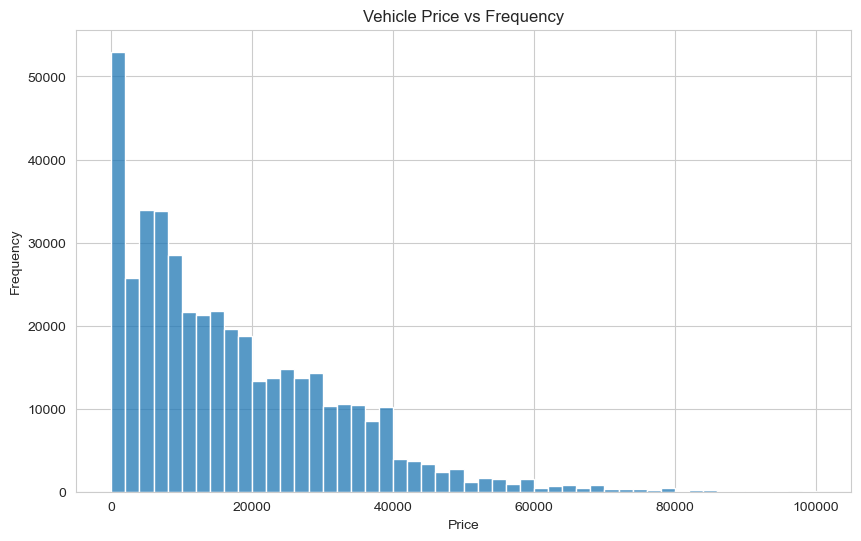

In [9]:
plt.figure(figsize=(10,6))

sns.histplot(
    df[df['price'] < 100000]['price'],
    bins=50
)

plt.title('Vehicle Price vs Frequency')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

# Vehicle Price vs Frequency Findings

Vehicle prices are not evenly distributed and show a strong right skew, meaning that most vehicles are concentrated in lower price ranges while a smaller number of listings are priced much higher. Standard everyday vehicles make up the majority of listings and higher-end or luxury vehicles appear less frequently.

In [10]:
filtered_df = df[
    (df['price'] > 1000) &
    (df['price'] < 100000) &
    (df['odometer'] > 0) &
    (df['odometer'] < 300000)
]

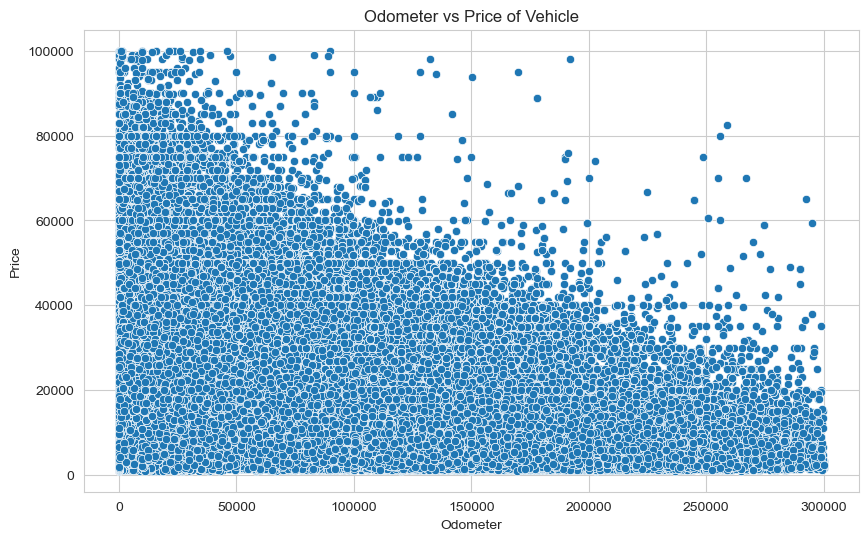

In [11]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=filtered_df,
    x='odometer',
    y='price'
)


plt.title('Odometer vs Price of Vehicle')
plt.xlabel('Odometer')
plt.ylabel('Price')

plt.show()

# Odometer vs Price of Vehicle Findings 

There is a clear trend showing that vehicles with lower mileage are generally priced higher, while vehicles with higher odometer readings tend to sell for less. At the same time, mileage is not the only factor affecting price. The variation in the data suggests that things like manufacturer, vehicle condition, and model year also play a role in determining resale value.

In [12]:
filtered_df = df[
    (df['price'] > 1000) &
    (df['price'] < 100000) &
    (df['odometer'] > 0) &
    (df['odometer'] < 300000)
]

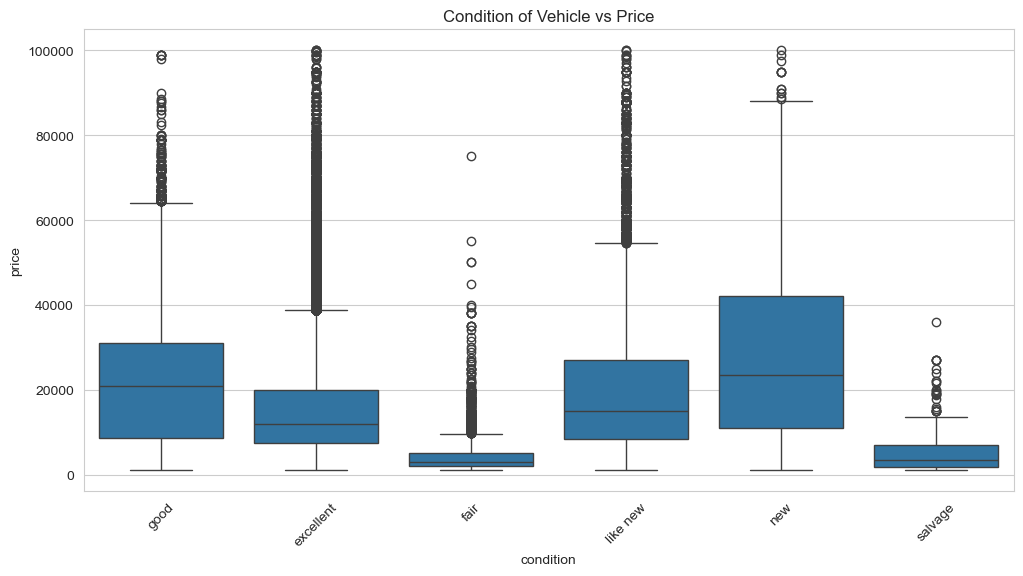

In [13]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=filtered_df,
    x='condition',
    y='price'
)

plt.xticks(rotation=45)

plt.title('Condition of Vehicle vs Price')

plt.show()

# Condition of Vehicle vs Price Findings

COndition of the cehicle has a noticeable impact on resale price. Vehicles listed as new or like new are typically priced much higher, while vehicles in fair or salvage condition are usually valued much lower, as expected. There is overlap with different condition categories, which suggests that other factors such as mileage, manufacturer, and vehicle age also affect vehicle pricing.

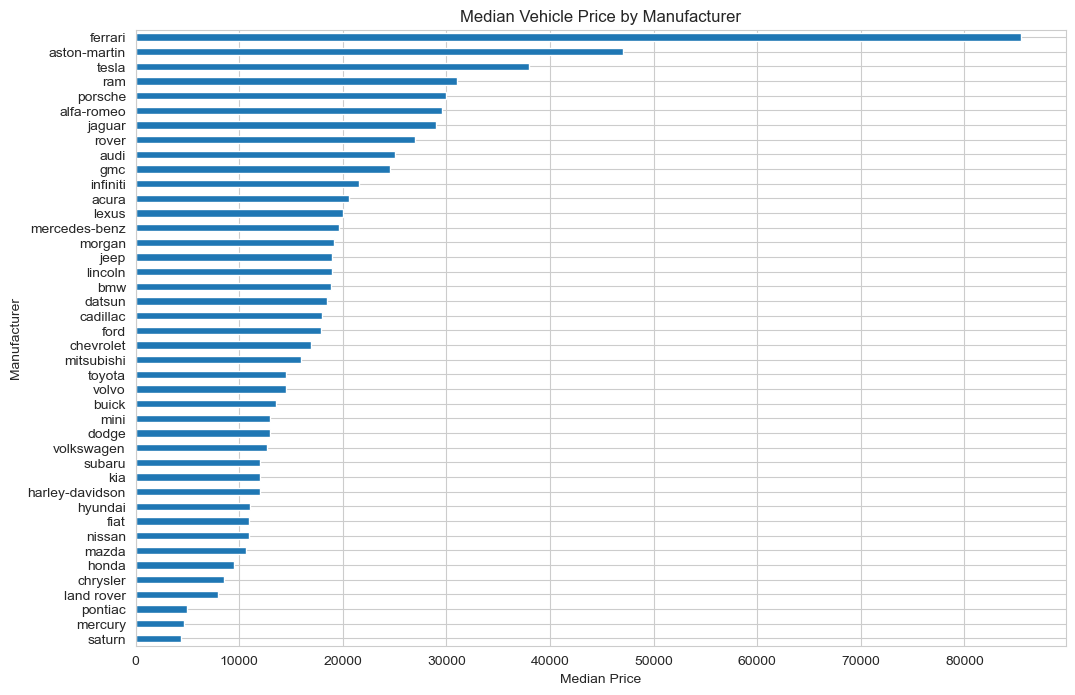

In [14]:
median_price = filtered_df.groupby('manufacturer')['price'].median().sort_values()

plt.figure(figsize=(12,8))

median_price.plot(kind='barh')

plt.title('Median Vehicle Price by Manufacturer')
plt.xlabel('Median Price')
plt.ylabel('Manufacturer')

plt.show()

# Median Price vs Manufacturer Findings

Median vehicle prices vary significantly across manufacturers. Luxury and premium brands such as Ferrari, Aston Martin, and Tesla generally maintain substantially higher resale values compared to economy-focused manufacturers.

Median prices were used instead of averages to reduce the influence of extreme outliers and better represent typical pricing behavior across manufacturers.

# 3. Data Preparation

In [15]:
# cleaning datasets

clean_df = df[
    (df['price'] > 1000) &
    (df['price'] < 100000) &
    (df['odometer'] > 0) &
    (df['odometer'] < 300000)
].copy()

In [16]:
clean_df.shape

(372864, 18)

# Cleaning datasets

Before building the models, the dataset was cleaned by removing vehicles with unrealistic price and mileage values. Listings priced below $1,000 or above $100,000 were excluded to reduce the effect of extreme outliers and possible input errors. Unreasonable odometer readings on vehicles were  removed to improve the quality and consistency of the dataset.

In [17]:
clean_df.columns

Index(['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN',
       'drive', 'size', 'type', 'paint_color', 'state'],
      dtype='object')

In [18]:
clean_df = clean_df.drop(
    columns=['id', 'VIN'],
    errors='ignore'
)

# Selecting Features

Identifier-based columns such as VIN and other non-predictive fields were removed from the dataset to simplify modeling and reduce unnecessary noise.

The remaining features were retained based on their potential relationship to vehicle pricing.

In [19]:
clean_df.isnull().sum().sort_values(ascending=False)

size            267785
cylinders       151809
condition       140520
drive           112283
paint_color     105797
type             78542
manufacturer     13725
title_status      6117
model             4103
fuel              2280
transmission      1505
year              1077
price                0
region               0
odometer             0
state                0
dtype: int64

In [20]:
selected_features = [
    'year',
    'manufacturer',
    'condition',
    'fuel',
    'transmission',
    'drive',
    'type',
    'title_status',
    'odometer'
]

X = clean_df[selected_features]

y = clean_df['price']

# Selecting Features

The features used for modeling were chosen based on how relevant they appeared to vehicle pricing and the overall quality of the data. Columns with a large number of missing values or limited usefulness for predicting price were removed to keep the models simpler and more reliable.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((298291, 9), (74573, 9))

In [22]:
categorical_features = [
    'manufacturer',
    'condition',
    'fuel',
    'transmission',
    'drive',
    'type',
    'title_status'
]

numerical_features = [
    'year',
    'odometer'
]

In [23]:
model_df = clean_df[selected_features + ['price']].dropna()

In [24]:
model_df = pd.get_dummies(
    model_df,
    drop_first=True
)

In [25]:
X = model_df.drop(columns=['price'])

y = model_df['price']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 4. Modeling

In [27]:
# Linear Regression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [28]:
y_pred_lr = lr_model.predict(X_test)

In [29]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)

print("Linear Regression R²:", r2_lr)

Linear Regression RMSE: 7417.636277048496
Linear Regression R²: 0.6620418650826947


In [30]:
cv_scores_lr = cross_val_score(
    lr_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Average Cross-Validation R²:", cv_scores_lr.mean())

Average Cross-Validation R²: 0.6632608195545189


# Results from Linear Regression 

The linear regression model was able to predict vehicle prices reasonably well using the selected features. The R² score shows how much of the variation in vehicle prices is explained by the model, while RMSE represents the average prediction error in terms of dollars.
Cross-validation showed consistently the model performed across different portions of the dataset.

In [31]:
ridge_model = Ridge()

In [32]:
param_grid = {
    'alpha': [0.1, 1.0, 10.0, 100.0]
}

In [33]:
grid_search = GridSearchCV(
    ridge_model,
    param_grid,
    cv=5,
    scoring='r2'
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.1, 1.0, 10.0, 100.0]}, scoring='r2')

In [34]:
print("Best Alpha:", grid_search.best_params_)

print("Best Cross-Validation Score:", grid_search.best_score_)

Best Alpha: {'alpha': 0.1}
Best Cross-Validation Score: 0.6680324822744794


In [35]:
y_pred_ridge = grid_search.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge RMSE:", rmse_ridge)

print("Ridge R²:", r2_ridge)

Ridge RMSE: 7417.697137594737
Ridge R²: 0.6620363192725984


# Results from Ridge Regression

Ridge Regression was applied to help control model complexity and improve how well the model performs on unseen data. GridSearchCV was used to test different alpha values and determine which level of regularization produced the best results through cross-validation. Overall, the Ridge model performed well and helped reduce the chances of overfitting.

In [36]:
lasso_model = Lasso(alpha=1.0)

In [37]:
lasso_model.fit(X_train, y_train)

Lasso()

In [38]:
y_pred_lasso = lasso_model.predict(X_test)

In [39]:
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso RMSE:", rmse_lasso)

print("Lasso R²:", r2_lasso)

Lasso RMSE: 7421.863875290344
Lasso R²: 0.6616565244394096


# Results from Lasso Regression 

Lasso Regression showed the same predictive perfromance as the other 2 models, while applying strong feature selection.Lasso Regression helps simplify the model and reduce complexity by shrinking less important coefficients toward 0.



In [40]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],
    'R² Score': [
        r2_lr,
        r2_ridge,
        r2_lasso
    ],
    'RMSE': [
        rmse_lr,
        rmse_ridge,
        rmse_lasso
    ]
})

results

,Model,R² Score,RMSE
0,Linear Regression,0.662042,7417.636277
1,Ridge Regression,0.662036,7417.697138
2,Lasso Regression,0.661657,7421.863875


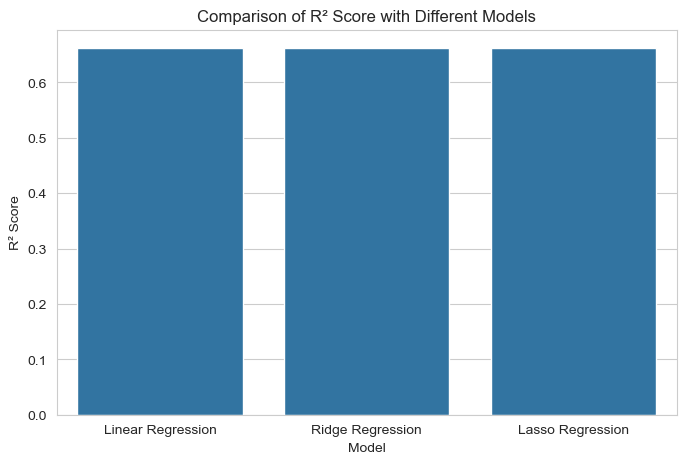

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='R² Score'
)

plt.title('Comparison of R² Score with Different Models')
plt.ylabel('R² Score')

plt.show()

# 5. Evaluation

# Main Evaluation Metric (R²)

It measures how much variability in vehicle prices can be explained by the selected features.

RMSE was also used because it provides an interpretable estimate of prediction error in dollar amounts, which is meaningful from a business perspective.

Cross-validation was applied to evaluate model consistency and generalization performance across multiple subsets of the dataset.

Among the evaluated models, Ridge Regression demonstrated strong predictive performance while helping reduce the risk of overfitting through regularization.

# Comparing Different Models

The three regression models produced relatively similar predictive performance; however, the regularized models provided additional control over model complexity.

Ridge Regression improved generalization by penalizing large coefficients, while Lasso Regression additionally performed feature selection by shrinking less important coefficients toward zero.

The results suggest that vehicle price is influenced by a combination of factors including mileage, model year, manufacturer, transmission type, and overall vehicle condition.

# Evaluation Insights

The comparison of model performance indicates that all regression models demonstrated moderate predictive capability.

Regularized regression techniques such as Ridge and Lasso helped improve model robustness while maintaining comparable predictive accuracy.

# 6. Findings and Recommendations

# Key Findings

The analysis identified several important factors that influence used vehicle pricing.

Key findings include:

- Vehicle mileage (odometer reading) has a strong negative relationship with price. Vehicles with lower mileage generally maintain higher resale values.
- Vehicle condition significantly impacts pricing, with new and like new vehicles commanding substantially higher prices than salvage or fair condition vehicles.
- Manufacturer also plays a major role in resale value. Luxury and premium brands such as Ferrari, Aston Martin, and Tesla tend to maintain higher median prices compared to economy-focused brands.
- Model year contributes positively to vehicle value, with newer vehicles generally associated with higher prices.
- Regularized regression models such as Ridge and Lasso demonstrated strong predictive performance while helping control model complexity and overfitting.

## Recommendations for Used Car Dealerships

Based on the analysis, the following recommendations are suggested for used car dealerships:

1. Prioritize lower mileage vehicles when purchasing inventory, as mileage strongly impacts resale value.

2. Focus on acquiring vehicles in excellent, like new, or new condition whenever possible to maximize resale pricing potential.

3. Consider maintaining inventory from manufacturers with historically stronger resale values, particularly premium and luxury brands.

4. Use predictive pricing models to support inventory purchasing decisions and improve pricing consistency across listings.

5. Continue monitoring market trends and vehicle features to further improve pricing accuracy and inventory optimization.



## Next Steps

Potential future improvements for this project include:

- Incorporating additional vehicle features and external market data.
- Performing deeper feature engineering and additional hyperparameter tuning.
- Evaluating real-time pricing trends across geographic regions.